In [3]:
# ============================================
# Step 1: Mount Google Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# Change to your project folder
import os

project_path = "/content/drive/MyDrive/Custom_Object_Character_Recognition"
os.chdir(project_path)

print("Current Working Directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current Working Directory: /content/drive/MyDrive/Custom_Object_Character_Recognition


In [4]:
# ==========================================================
# STEP 2: Download the Roboflow Dataset
# Purpose:
# Download the annotated dataset (images + labels + data.yaml)
# from Roboflow into our project folder.
# ==========================================================

# Install the Roboflow library
!pip install -q roboflow

from roboflow import Roboflow
import os
import shutil

# Connect to your Roboflow account
rf = Roboflow(api_key="sbWUChwHQJh4qiaJETW2")

# Open your project
project = rf.workspace("workwithdevesh99-gmail-com").project("lab-of-ocr")

# Select dataset version 1
version = project.version(1)

# Download the dataset in YOLOv8 format
dataset = version.download("yolov8")

# Create a folder inside our project to store the dataset
destination = "data/roboflow_dataset"

# Remove the folder if it already exists (optional)
if os.path.exists(destination):
    shutil.rmtree(destination)

# Move the downloaded dataset into our project folder
shutil.move(dataset.location, destination)

print("=" * 50)
print("Dataset Downloaded Successfully!")
print("Dataset Location:", os.path.abspath(destination))
print("=" * 50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.2 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Lab-of-OCR-1 in yolov8:: 100%|██████████| 205/205 [00:01<00:00, 116.94it/s]


Dataset Downloaded Successfully!
Dataset Location: /content/drive/MyDrive/Custom_Object_Character_Recognition/data/roboflow_dataset


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ==========================================================
# STEP 3: Verify the Downloaded Dataset
# Purpose:
# Check that all required folders and files exist before
# starting YOLO training.
# ==========================================================

import os

dataset_path = "data/roboflow_dataset"

print("=" * 60)
print("Dataset Folder Structure")
print("=" * 60)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

print("\n" + "=" * 60)
print("Checking Important Files")
print("=" * 60)

important_files = [
    "data/roboflow_dataset/data.yaml",
    "data/roboflow_dataset/train/images",
    "data/roboflow_dataset/train/labels",
    "data/roboflow_dataset/valid/images",
    "data/roboflow_dataset/valid/labels",
    "data/roboflow_dataset/test/images",
    "data/roboflow_dataset/test/labels",
]

for item in important_files:
    if os.path.exists(item):
        print(f"✅ Found : {item}")
    else:
        print(f"❌ Missing : {item}")

Dataset Folder Structure
roboflow_dataset/
    test/
        images/
        labels/
    train/
        images/
        labels/
    valid/
        images/
        labels/

Checking Important Files
✅ Found : data/roboflow_dataset/data.yaml
✅ Found : data/roboflow_dataset/train/images
✅ Found : data/roboflow_dataset/train/labels
✅ Found : data/roboflow_dataset/valid/images
✅ Found : data/roboflow_dataset/valid/labels
✅ Found : data/roboflow_dataset/test/images
✅ Found : data/roboflow_dataset/test/labels


In [7]:
# ==========================================================
# STEP 4: Install Ultralytics (YOLOv8)
# Purpose:
# Install the official YOLOv8 library and verify that it
# has been installed correctly.
# ==========================================================

# Install Ultralytics
!pip install -q ultralytics

# Import the library
from ultralytics import YOLO

# Print the installed version
import ultralytics

print("=" * 60)
print("Ultralytics Installed Successfully!")
print("Version :", ultralytics.__version__)
print("=" * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics Installed Successfully!
Version : 8.4.83


In [8]:
# ==========================================================
# STEP 5: Verify the Training Environment
# Purpose:
# Check Python, PyTorch, CUDA, and GPU information before
# training the YOLO model.
# ==========================================================

import torch
import platform

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print(f"Python Version : {platform.python_version()}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name       : {torch.cuda.get_device_name(0)}")
    print(f"GPU Count      : {torch.cuda.device_count()}")
else:
    print("GPU Name       : No GPU Detected")

print("=" * 60)

SYSTEM INFORMATION
Python Version : 3.12.13
PyTorch Version: 2.11.0+cu128
CUDA Available : True
GPU Name       : Tesla T4
GPU Count      : 1


In [9]:
# ==========================================================
# STEP 6: Load the Pre-trained YOLOv8 Model
# Purpose:
# Load the YOLOv8 Nano (yolov8n.pt) model that will be
# fine-tuned on our custom OCR dataset.
# ==========================================================

from ultralytics import YOLO

# Load the pre-trained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

print("=" * 60)
print("YOLOv8 Model Loaded Successfully!")
print("Model Name : yolov8n.pt")
print("=" * 60)

YOLOv8 Model Loaded Successfully!
Model Name : yolov8n.pt


In [10]:
# ==========================================================
# STEP 7: Verify the data.yaml File
# Purpose:
# Display the contents of data.yaml to verify dataset paths
# and class names before training.
# ==========================================================

yaml_path = "data/roboflow_dataset/data.yaml"

print("=" * 60)
print("Contents of data.yaml")
print("=" * 60)

with open(yaml_path, "r") as file:
    print(file.read())

print("=" * 60)

Contents of data.yaml
names:
- Clinical_Conditions
- Name
- Ref_By
- Reference_Range
- Technology
- Test_Asked
- Test_Name
- Unit
- Value
nc: 9
roboflow:
  license: CC BY 4.0
  project: lab-of-ocr
  url: https://universe.roboflow.com/workwithdevesh99-gmail-com/lab-of-ocr/dataset/1
  version: 1
  workspace: workwithdevesh99-gmail-com
test: ../test/images
train: ../train/images
val: ../valid/images



In [11]:
# ==========================================================
# STEP 8: Train the YOLOv8 Model
# Purpose:
# Fine-tune the pre-trained YOLOv8 Nano model using our
# custom OCR dataset.
# ==========================================================

# Train the model
results = model.train(
    data="data/roboflow_dataset/data.yaml",  # Dataset configuration
    epochs=50,                               # Number of training passes
    imgsz=640,                               # Image size
    batch=16,                                # Batch size
    project="models",                        # Save all training results here
    name="lab_report_ocr_v1",                # Name of this training run
    exist_ok=True                            # Overwrite if the folder already exists
)

print("=" * 60)
print("Training Completed!")
print("=" * 60)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/roboflow_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lab_report_ocr_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [12]:
# ==========================================================
# STEP 9: Test the Trained YOLO Model on One Image
# Purpose:
# Load the best trained model and perform object detection
# on a single laboratory report image.
# ==========================================================

from ultralytics import YOLO

# Load the best trained model
model = YOLO(
    "runs/detect/models/lab_report_ocr_v1/weights/best.pt"
)

# Path to one test image
image_path = "data/roboflow_dataset/test/images"

# Run prediction
results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)

print("=" * 60)
print("Prediction Completed Successfully!")
print("=" * 60)


image 1/10 /content/drive/MyDrive/Custom_Object_Character_Recognition/data/roboflow_dataset/test/images/thyrocare_0_122_jpg.rf.8eeaef81c0be4a785e05a26dcbb2883c.jpg: 448x640 1 Clinical_Conditions, 1 Name, 1 Ref_By, 1 Reference_Range, 1 Technology, 1 Test_Asked, 1 Test_Name, 1 Unit, 1 Value, 39.9ms
image 2/10 /content/drive/MyDrive/Custom_Object_Character_Recognition/data/roboflow_dataset/test/images/thyrocare_0_36_jpg.rf.8dcbc0eddf01fc797beb82d8a8dc3134.jpg: 640x416 1 Clinical_Conditions, 1 Name, 1 Ref_By, 2 Technologys, 1 Test_Asked, 2 Test_Names, 2 Units, 2 Values, 44.1ms
image 3/10 /content/drive/MyDrive/Custom_Object_Character_Recognition/data/roboflow_dataset/test/images/thyrocare_0_4670_jpg.rf.ed8189fd13cf96c2e1a0e25428de7c8a.jpg: 448x640 1 Clinical_Conditions, 1 Name, 1 Ref_By, 1 Reference_Range, 1 Technology, 1 Test_Asked, 1 Test_Name, 1 Unit, 1 Value, 7.5ms
image 4/10 /content/drive/MyDrive/Custom_Object_Character_Recognition/data/roboflow_dataset/test/images/thyrocare_0_5074_

In [13]:
# ==========================================================
# STEP 10: Crop Detected Regions from One Test Image
# Purpose:
# Detect objects using the trained YOLO model and save each
# detected region as a separate cropped image.
# ==========================================================

from ultralytics import YOLO
import cv2
import os
from glob import glob

# Load the trained YOLO model
model = YOLO("runs/detect/models/lab_report_ocr_v1/weights/best.pt")

# Select the first image from the test dataset
image_path = sorted(glob("data/roboflow_dataset/test/images/*"))[0]

print(f"Processing Image:\n{image_path}\n")

# Read the image using OpenCV
image = cv2.imread(image_path)

# Run object detection
results = model.predict(image_path, conf=0.25)

# Create output folder for cropped images
output_folder = "outputs/crops"
os.makedirs(output_folder, exist_ok=True)

# Get class names
class_names = model.names

# Crop and save each detected object
for i, box in enumerate(results[0].boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    class_id = int(box.cls[0])
    class_name = class_names[class_id]

    # Crop the detected region
    crop = image[y1:y2, x1:x2]

    # Save cropped image
    save_path = os.path.join(output_folder, f"{class_name}_{i+1}.jpg")
    cv2.imwrite(save_path, crop)

    print(f"Saved: {save_path}")

print("\n" + "=" * 60)
print("All detected regions have been cropped successfully!")
print(f"Cropped images saved in: {output_folder}")
print("=" * 60)

Processing Image:
data/roboflow_dataset/test/images/thyrocare_0_122_jpg.rf.8eeaef81c0be4a785e05a26dcbb2883c.jpg


image 1/1 /content/drive/MyDrive/Custom_Object_Character_Recognition/data/roboflow_dataset/test/images/thyrocare_0_122_jpg.rf.8eeaef81c0be4a785e05a26dcbb2883c.jpg: 448x640 1 Clinical_Conditions, 1 Name, 1 Ref_By, 1 Reference_Range, 1 Technology, 1 Test_Asked, 1 Test_Name, 1 Unit, 1 Value, 13.9ms
Speed: 7.4ms preprocess, 13.9ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Saved: outputs/crops/Reference_Range_1.jpg
Saved: outputs/crops/Technology_2.jpg
Saved: outputs/crops/Name_3.jpg
Saved: outputs/crops/Test_Asked_4.jpg
Saved: outputs/crops/Test_Name_5.jpg
Saved: outputs/crops/Value_6.jpg
Saved: outputs/crops/Unit_7.jpg
Saved: outputs/crops/Clinical_Conditions_8.jpg
Saved: outputs/crops/Ref_By_9.jpg

All detected regions have been cropped successfully!
Cropped images saved in: outputs/crops


In [14]:
# ==========================================================
# STEP 11: Install Tesseract OCR
# Purpose:
# Install the Tesseract OCR engine and the Python library
# required to read text from the cropped images.
# ==========================================================

# Install the Tesseract OCR engine
!apt-get install -y tesseract-ocr

# Install the Python wrapper
!pip install -q pytesseract

# Import pytesseract
import pytesseract

print("=" * 60)
print("Tesseract OCR Installed Successfully!")
print("=" * 60)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
Tesseract OCR Installed Successfully!


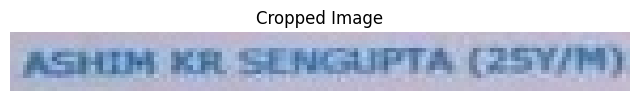

OCR RESULT
ASHIM KR SENGUPTA (25¥/M)



In [15]:
# ==========================================================
# STEP 12: Test Tesseract OCR on One Cropped Image
# Purpose:
# Read text from one cropped image to verify that OCR is
# working correctly before processing all detected regions.
# ==========================================================

import cv2
import matplotlib.pyplot as plt
import pytesseract

# Path of one cropped image
image_path = "outputs/crops/Name_3.jpg"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB (for correct display)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the cropped image
plt.figure(figsize=(8,3))
plt.imshow(image_rgb)
plt.title("Cropped Image")
plt.axis("off")
plt.show()

# Extract text using Tesseract OCR
text = pytesseract.image_to_string(image_rgb)

print("=" * 60)
print("OCR RESULT")
print("=" * 60)
print(text)
print("=" * 60)

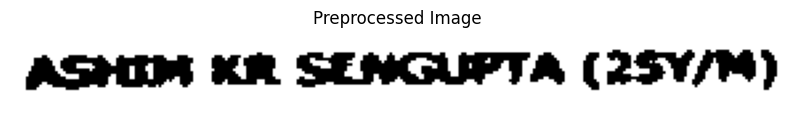

OCR RESULT AFTER PREPROCESSING
ASHIM KR SENGUPTA (257/™)



In [16]:
# ==========================================================
# STEP 13: Improve OCR Accuracy Using Image Preprocessing
# Purpose:
# Apply preprocessing before OCR and compare the extracted text.
# ==========================================================

import cv2
import matplotlib.pyplot as plt
import pytesseract

# Read the cropped image
image_path = "outputs/crops/Name_3.jpg"
image = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Enlarge image (2x)
gray = cv2.resize(
    gray,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_CUBIC
)

# Apply binary thresholding
_, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Display the processed image
plt.figure(figsize=(10,3))
plt.imshow(thresh, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

# OCR on the processed image
text = pytesseract.image_to_string(thresh)

print("=" * 60)
print("OCR RESULT AFTER PREPROCESSING")
print("=" * 60)
print(text)
print("=" * 60)

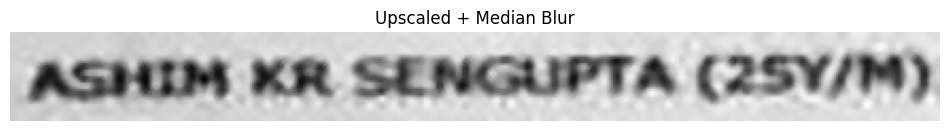

OCR RESULT (PSM 7)
ASHIM KR SENGUPTA (2S5Y/™)



In [17]:
# ==========================================================
# STEP 14: OCR with Better Preprocessing (No Threshold)
# Purpose:
# Improve OCR by enlarging the image and using the correct
# Tesseract Page Segmentation Mode (PSM 7).
# ==========================================================

import cv2
import matplotlib.pyplot as plt
import pytesseract

# Read cropped image
image_path = "outputs/crops/Name_3.jpg"
image = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Upscale 3x
gray = cv2.resize(
    gray,
    None,
    fx=3,
    fy=3,
    interpolation=cv2.INTER_CUBIC
)

# Remove small noise
gray = cv2.medianBlur(gray, 3)

# Display processed image
plt.figure(figsize=(12,3))
plt.imshow(gray, cmap="gray")
plt.title("Upscaled + Median Blur")
plt.axis("off")
plt.show()

# OCR using PSM 7 (single text line)
config = "--psm 7"

text = pytesseract.image_to_string(gray, config=config)

print("=" * 60)
print("OCR RESULT (PSM 7)")
print("=" * 60)
print(text)
print("=" * 60)

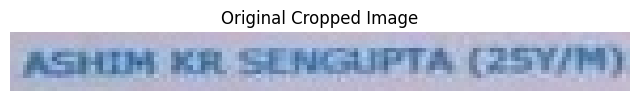

OCR RESULT (Optimized Tesseract)
ASHIMKRSENGUPTA(25V/M)



In [18]:
# ==========================================================
# STEP 15: Optimize Tesseract Configuration
# Purpose:
# Use Tesseract's OCR settings instead of image preprocessing
# to improve recognition accuracy.
# ==========================================================

import cv2
import matplotlib.pyplot as plt
import pytesseract

# Read the original cropped image (NO preprocessing)
image_path = "outputs/crops/Name_3.jpg"
image = cv2.imread(image_path)

# Convert to RGB for display and OCR
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show original image
plt.figure(figsize=(8,3))
plt.imshow(image_rgb)
plt.title("Original Cropped Image")
plt.axis("off")
plt.show()

# Tesseract configuration
config = (
    "--oem 3 "
    "--psm 7 "
    "-c tessedit_char_whitelist="
    "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789()/-"
)

# OCR
text = pytesseract.image_to_string(image_rgb, config=config)

print("=" * 60)
print("OCR RESULT (Optimized Tesseract)")
print("=" * 60)
print(text)
print("=" * 60)

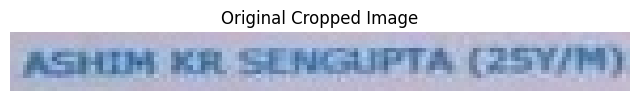

OCR RESULT (PSM 13)
ASHIMKRSENGUPTA(25V/M)



In [19]:
# ==========================================================
# STEP 16: Test Tesseract with PSM 13
# Purpose:
# Compare PSM 13 with PSM 7 to see which produces better OCR.
# ==========================================================

import cv2
import matplotlib.pyplot as plt
import pytesseract

# Read original cropped image
image_path = "outputs/crops/Name_3.jpg"
image = cv2.imread(image_path)

# Convert to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(8,3))
plt.imshow(image_rgb)
plt.title("Original Cropped Image")
plt.axis("off")
plt.show()

# Tesseract configuration (PSM 13)
config = (
    "--oem 3 "
    "--psm 13 "
    "-c tessedit_char_whitelist="
    "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789()/-"
)

# OCR
text = pytesseract.image_to_string(image_rgb, config=config)

print("=" * 60)
print("OCR RESULT (PSM 13)")
print("=" * 60)
print(text)
print("=" * 60)

In [20]:
# ==========================================================
# STEP 17: Install EasyOCR
# Purpose:
# Install the EasyOCR library so we can compare it with
# Tesseract on the same cropped image.
# ==========================================================

# Install EasyOCR
!pip install -q easyocr

# Import EasyOCR
import easyocr

print("=" * 60)
print("EasyOCR Installed Successfully!")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 32.4 MB/s eta 0:00:00
EasyOCR Installed Successfully!


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

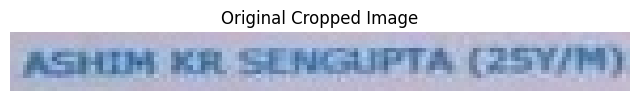

EasyOCR RESULT


In [21]:
# ==========================================================
# STEP 18: Test EasyOCR on One Cropped Image
# Purpose:
# Read the same cropped image using EasyOCR and compare
# the result with Tesseract.
# ==========================================================

import easyocr
import cv2
import matplotlib.pyplot as plt

# Create EasyOCR reader (English)
reader = easyocr.Reader(['en'], gpu=True)

# Read image
image_path = "outputs/crops/Name_3.jpg"
image = cv2.imread(image_path)

# Display image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,3))
plt.imshow(image_rgb)
plt.title("Original Cropped Image")
plt.axis("off")
plt.show()

# Perform OCR
results = reader.readtext(image_path)

print("=" * 60)
print("EasyOCR RESULT")
print("=" * 60)

for detection in results:
    print("Detected Text :", detection[1])
    print("Confidence    :", round(detection[2], 4))
    print("-" * 40)

print("=" * 60)

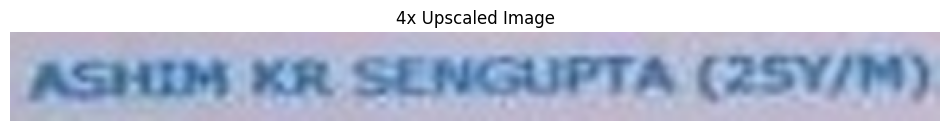

EasyOCR RESULT (Upscaled Image)
Detected Text : ASN XK SNGUTA (Z5ir
Confidence    : 0.2322
----------------------------------------


In [22]:
# ==========================================================
# STEP 19: Upscale Image Before EasyOCR
# Purpose:
# Increase image size before OCR to see if EasyOCR performs
# better on enlarged text.
# ==========================================================

import cv2
import easyocr
import matplotlib.pyplot as plt

# Initialize EasyOCR (reuse downloaded model)
reader = easyocr.Reader(['en'], gpu=True)

# Read image
image_path = "outputs/crops/Name_3.jpg"
image = cv2.imread(image_path)

# Upscale image 4x
upscaled = cv2.resize(
    image,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_CUBIC
)

# Save temporary image
temp_path = "outputs/upscaled_name.jpg"
cv2.imwrite(temp_path, upscaled)

# Display image
plt.figure(figsize=(12,3))
plt.imshow(cv2.cvtColor(upscaled, cv2.COLOR_BGR2RGB))
plt.title("4x Upscaled Image")
plt.axis("off")
plt.show()

# OCR
results = reader.readtext(temp_path)

print("=" * 60)
print("EasyOCR RESULT (Upscaled Image)")
print("=" * 60)

if len(results) == 0:
    print("No text detected.")
else:
    for result in results:
        print("Detected Text :", result[1])
        print("Confidence    :", round(result[2], 4))
        print("-" * 40)

print("=" * 60)

In [23]:
# ==========================================================
# STEP 20: Test Optimized Tesseract on Multiple Fields
# Purpose:
# Verify that our optimized OCR works well on different
# types of cropped regions before building the final pipeline.
# ==========================================================

import os
import cv2
import pytesseract

# Optimized Tesseract configuration
config = (
    "--oem 3 "
    "--psm 7 "
    "-c tessedit_char_whitelist="
    "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789().,/()-:"
)

# Fields to test
test_images = [
    "outputs/crops/Name_3.jpg",
    "outputs/crops/Test_Name_5.jpg",
    "outputs/crops/Value_6.jpg"
]

print("=" * 70)
print("OCR RESULTS FOR MULTIPLE FIELDS")
print("=" * 70)

for image_path in test_images:

    if not os.path.exists(image_path):
        print(f"❌ File not found: {image_path}")
        continue

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    text = pytesseract.image_to_string(image_rgb, config=config).strip()

    print(f"\nField : {os.path.basename(image_path)}")
    print("-" * 50)
    print(text)

OCR RESULTS FOR MULTIPLE FIELDS

Field : Name_3.jpg
--------------------------------------------------
ASHIMKRSENGUPTA(25V/M)

Field : Test_Name_5.jpg
--------------------------------------------------
Toracremonner Bs pa

Field : Value_6.jpg
--------------------------------------------------
a


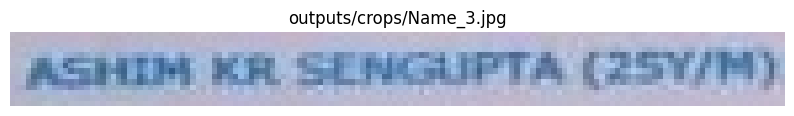

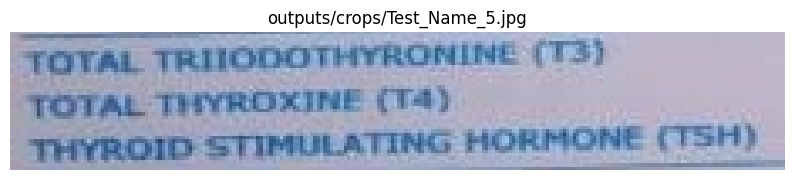

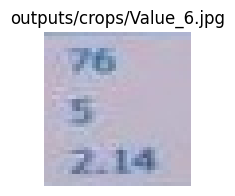

In [24]:
# ==========================================================
# STEP 21: Display the Cropped Images
# Purpose:
# Check whether the cropped regions produced by YOLO
# are large enough for OCR.
# ==========================================================

import cv2
import matplotlib.pyplot as plt

images = [
    "outputs/crops/Name_3.jpg",
    "outputs/crops/Test_Name_5.jpg",
    "outputs/crops/Value_6.jpg"
]

for img_path in images:

    image = cv2.imread(img_path)

    if image is None:
        print(f"Could not open: {img_path}")
        continue

    plt.figure(figsize=(10,2))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(img_path)
    plt.axis("off")
    plt.show()

In [25]:
# ==========================================================
# STEP 21: Create Dictionary to Store OCR Results
#
# Purpose:
# Create an empty dictionary where we will save the
# OCR text extracted from each detected field.
# ==========================================================

# Empty dictionary
ocr_results = {}

print("=" * 60)
print("OCR Results Dictionary Created Successfully!")
print("=" * 60)

print("Current Dictionary:")
print(ocr_results)

OCR Results Dictionary Created Successfully!
Current Dictionary:
{}


In [26]:
# ==========================================================
# STEP 22: Get All Cropped Images
#
# Purpose:
# Automatically find all cropped images generated by YOLO.
# This makes the pipeline work for any lab report.
# ==========================================================

import os

crop_folder = "outputs/crops"

# Get all JPG cropped images
crop_files = sorted([
    file for file in os.listdir(crop_folder)
    if file.endswith(".jpg")
])

print("=" * 60)
print("CROPPED IMAGES FOUND")
print("=" * 60)

for i, file in enumerate(crop_files, start=1):
    print(f"{i}. {file}")

print("\nTotal Cropped Images:", len(crop_files))

CROPPED IMAGES FOUND
1. Clinical_Conditions_8.jpg
2. Name_3.jpg
3. Ref_By_9.jpg
4. Reference_Range_1.jpg
5. Technology_2.jpg
6. Test_Asked_4.jpg
7. Test_Name_5.jpg
8. Unit_7.jpg
9. Value_6.jpg

Total Cropped Images: 9


In [27]:
# ==========================================================
# STEP 23: Read ONE Crop and Store in Dictionary
#
# Purpose:
# Read the Name crop, perform OCR, and save the
# extracted text into our dictionary.
# ==========================================================

import cv2
import pytesseract

# Path of the cropped image
image_path = "outputs/crops/Name_3.jpg"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Tesseract configuration
config = (
    "--oem 3 "
    "--psm 7 "
    "-c tessedit_char_whitelist="
    "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789().,/()-:"
)

# Perform OCR
text = pytesseract.image_to_string(image_rgb, config=config).strip()

# Save into dictionary
ocr_results["Name"] = text

print("=" * 60)
print("OCR Result Stored Successfully!")
print("=" * 60)

print(ocr_results)

OCR Result Stored Successfully!
{'Name': 'ASHIMKRSENGUPTA(25V/M)'}


In [28]:
# ==========================================================
# STEP 24: OCR All Cropped Images Automatically
#
# Purpose:
# Read every cropped image, perform OCR, and store the
# extracted text into the dictionary automatically.
# ==========================================================

import os
import cv2
import pytesseract

# Clear dictionary
ocr_results = {}

# OCR configuration
config = (
    "--oem 3 "
    "--psm 7 "
    "-c tessedit_char_whitelist="
    "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789().,/()-:"
)

crop_folder = "outputs/crops"

# Process every cropped image
for file in sorted(os.listdir(crop_folder)):

    if not file.endswith(".jpg"):
        continue

    image_path = os.path.join(crop_folder, file)

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Perform OCR
    text = pytesseract.image_to_string(
        image_rgb,
        config=config
    ).strip()

    # Extract field name from filename
    field_name = "_".join(file.split("_")[:-1])

    # Store result
    ocr_results[field_name] = text

# Display all extracted information
print("=" * 70)
print("FINAL OCR RESULTS")
print("=" * 70)

for key, value in ocr_results.items():
    print(f"\n{key}")
    print("-" * 40)
    print(value)

FINAL OCR RESULTS

Clinical_Conditions
----------------------------------------


Name
----------------------------------------
ASHIMKRSENGUPTA(25V/M)

Ref_By
----------------------------------------
eu

Reference_Range
----------------------------------------


Technology
----------------------------------------
cuia

Test_Asked
----------------------------------------
AAROGYAMA

Test_Name
----------------------------------------
Toracremonner Bs pa

Unit
----------------------------------------
a

Value
----------------------------------------
a


In [29]:
# ==========================================================
# STEP 25: Clean OCR Results
#
# Purpose:
# Clean the OCR text before exporting it.
# ==========================================================

import re

def clean_text(text):
    """Clean OCR output."""

    if not text:
        return ""

    # Remove leading/trailing spaces
    text = text.strip()

    # Replace multiple spaces/newlines with one space
    text = re.sub(r"\s+", " ", text)

    # Common OCR corrections for this project
    corrections = {
        "cuia": "CLIA",
        "Cuia": "CLIA",
        "Cuia": "CLIA",
    }

    for wrong, correct in corrections.items():
        text = text.replace(wrong, correct)

    return text

# Create a cleaned dictionary
cleaned_results = {}

for key, value in ocr_results.items():
    cleaned_results[key] = clean_text(value)

print("=" * 70)
print("CLEANED OCR RESULTS")
print("=" * 70)

for key, value in cleaned_results.items():
    print(f"\n{key}")
    print("-" * 40)
    print(value)

CLEANED OCR RESULTS

Clinical_Conditions
----------------------------------------


Name
----------------------------------------
ASHIMKRSENGUPTA(25V/M)

Ref_By
----------------------------------------
eu

Reference_Range
----------------------------------------


Technology
----------------------------------------
CLIA

Test_Asked
----------------------------------------
AAROGYAMA

Test_Name
----------------------------------------
Toracremonner Bs pa

Unit
----------------------------------------
a

Value
----------------------------------------
a


In [30]:
# ==========================================================
# STEP 26: Convert OCR Results to CSV
#
# Purpose:
# Convert the cleaned OCR results into a DataFrame
# and save them as a CSV file.
# ==========================================================

import pandas as pd

# Convert dictionary to DataFrame
df = pd.DataFrame(
    list(cleaned_results.items()),
    columns=["Field", "Extracted_Text"]
)

# Save CSV
csv_path = "outputs/ocr_results.csv"
df.to_csv(csv_path, index=False)

print("=" * 70)
print("CSV FILE CREATED SUCCESSFULLY!")
print("=" * 70)

print("\nSaved Location:")
print(csv_path)

print("\nDataFrame Preview:")
print(df)

CSV FILE CREATED SUCCESSFULLY!

Saved Location:
outputs/ocr_results.csv

DataFrame Preview:
                 Field          Extracted_Text
0  Clinical_Conditions                        
1                 Name  ASHIMKRSENGUPTA(25V/M)
2               Ref_By                      eu
3      Reference_Range                        
4           Technology                    CLIA
5           Test_Asked               AAROGYAMA
6            Test_Name     Toracremonner Bs pa
7                 Unit                       a
8                Value                       a


In [31]:
# ==========================================================
# STEP 27: Export OCR Results to JSON
#
# Purpose:
# Save the cleaned OCR results into a JSON file.
# ==========================================================

import json

# Output file path
json_path = "outputs/ocr_results.json"

# Save dictionary as JSON
with open(json_path, "w", encoding="utf-8") as json_file:
    json.dump(
        cleaned_results,
        json_file,
        indent=4,
        ensure_ascii=False
    )

print("=" * 70)
print("JSON FILE CREATED SUCCESSFULLY!")
print("=" * 70)

print("\nSaved Location:")
print(json_path)

print("\nJSON Preview:")

print(json.dumps(
    cleaned_results,
    indent=4,
    ensure_ascii=False
))

JSON FILE CREATED SUCCESSFULLY!

Saved Location:
outputs/ocr_results.json

JSON Preview:
{
    "Clinical_Conditions": "",
    "Name": "ASHIMKRSENGUPTA(25V/M)",
    "Ref_By": "eu",
    "Reference_Range": "",
    "Technology": "CLIA",
    "Test_Asked": "AAROGYAMA",
    "Test_Name": "Toracremonner Bs pa",
    "Unit": "a",
    "Value": "a"
}
